# Crystallization with Sedimentation Algorithm

## Overview
Simulation of competing particle sedimentation and crystal nucleation/growth in a colloidal suspension. The system evolves through four coupled processes at each timestep.

## Physical Setup
- **Suspension**: Packing fraction $\phi$ in vertical column of area $A$ and initial height $H_{\text{top}}$
- **Three density zones**: 
    
    1. Clear liquid (height $h_{\text{clear}}$) the CLEAR REGION
    2. Fluid+suspended crystals : the FLUID REGION, with volume $V_{\text{solution}} = A(h_{\text{clear}} - h_{\text{sed}})$ and where nucleation occurs
    3. Sediment (height $h_{\text{sed}}$): the CRYSTALLINE SEDIMENT REGION



- **Mass conservation**: Total particle number $N_{\text{total}} = \phi_0 A H_{\text{top}}$ is constant

## Algorithm Steps

### 1. Background Sedimentation

Particles settle with hindered settling velocity. Two models are available:

**Richardson–Zaki formula**:
$$v_{\text{bulk}} = v_0 \left(\frac{l}{d}\right)^2 (1 - \phi)^{4.65}$$

**Hayakawa-Ichki formula**:
$$v_{\text{bulk}} = v_0 \left(\frac{l}{d}\right)^2 \frac{(1 - \phi)^{3}}{1 + 2\phi + 1.492\phi(1-\phi)^3}$$

where $v_0$ is the Stokes terminal velocity, $l$ and $d$ are particle length scales. The clear height drops:

$$h_{\text{clear}} \to h_{\text{clear}} - v_{\text{bulk}} \, dt$$

Sediment accumulates at volume density $\phi_{\text{melt}}$:
$$h_{\text{sed}} \to h_{\text{sed}} + \frac{\phi_{\text{bulk}} v_{\text{bulk}}}{\phi_{\text{melt}} - \phi_{\text{bulk}}} dt$$

### 2. Nucleation
Nucleation events follow a Poisson process with density (events per unit volume per time):
$$\lambda = \dot{I}(\phi) \cdot V_{\text{solution}} \cdot dt$$

Each nucleus has initial volume $V_{\text{nuc}} = N_{\text{nucleus}} \cdot V_{\text{sphere}} / \phi_{\text{melt}}$

### 3. Crystal Growth and Settling
Each crystal grows volumetrically with rate proportional to surface area:
$$\frac{dV}{dt} = A_{\text{surf}} \cdot v_{\text{growth}} = 4\pi r^2 \cdot v_{\text{growth}}$$

where $r = (3V/(4\pi))^{1/3}$. Crystal sedimentation velocity follows the same hindered settling law. Crystals that reach $h_{\text{sed}}$ are removed and contribute to sediment:
$$h_{\text{sed}} \to h_{\text{sed}} + \frac{V_{\text{crystal}}}{A \cdot \phi_{\text{melt}}}$$

### 4. Mass Balance Update
Fluid volume accounting for suspended crystals:
$$V_{\text{fluid}} = A(h_{\text{clear}} - h_{\text{sed}}) - \sum_i V_i$$


New fluid packing fraction from total particle conservation:Repeat for next timestep with updated $\phi_{\text{fluid}}$ governing all rates.

$$\phi_{\text{fluid}} = \frac{N_{\text{total}} - \phi_{\text{melt}}(A h_{\text{sed}} + \sum_i V_i)}{V_{\text{fluid}}}$$

In [ ]:
## THINGS THAT ARE SUSPICIOUS:
## - the top interface height goes down quite slowly

import numpy as np
import matplotlib.pyplot as plt

class Crystal:
    def __init__(self, x, vol):
        self.x = x       # Vertical position (sigma)
        self.vol = vol   # Volume (sigma^3)


# --- Pure mathematical/utility functions ---

def hayakawa_ichki_expr(phi):
    """Hayakawa-Ichki expression for hindered settling."""
    return (1.0 - phi)**3 / (1.0 + 2.0*phi + 1.492*phi*(1.0 - phi)**3)


def sedimentation_speed_richardson_zaki(phi, vol, V0_SPHERE, D_SPHERE):
    """Richardson–Zaki hindered settling velocity [sigma/s].
    
    Parameters
    ----------
    phi : float
        Packing fraction
    vol : float
        Particle volume (sigma^3)
    V0_SPHERE : float
        Terminal velocity of single sphere
    D_SPHERE : float
        Diameter of background spheres
    """
    l = (6 * vol / np.pi)**(1/3)
    v0 = V0_SPHERE * (l / D_SPHERE)**2
    return v0 * (1.0 - phi)**4.65


def sedimentation_speed_hayakawa_ichki(phi, vol, V0_SPHERE, D_SPHERE):
    """Hayakawa-Ichki hindered settling velocity [sigma/s].
    
    Parameters
    ----------
    phi : float
        Packing fraction
    vol : float
        Particle volume (sigma^3)
    V0_SPHERE : float
        Terminal velocity of single sphere
    D_SPHERE : float
        Diameter of background spheres
    """
    l = (6 * vol / np.pi)**(1/3)
    v0 = V0_SPHERE * (l / D_SPHERE)**2
    return v0 * (1.0 - phi)**3 / (1.0 + 2.0*phi + 1.492*phi*(1.0 - phi)**3)


def sedimentation_speed(phi, vol, V0_SPHERE, D_SPHERE, model='hayakawa_ichki'):
    """Hindered settling velocity with choice of model [sigma/s].
    
    Parameters
    ----------
    phi : float
        Packing fraction
    vol : float
        Particle volume (sigma^3)
    V0_SPHERE : float
        Terminal velocity of single sphere
    D_SPHERE : float
        Diameter of background spheres
    model : str
        'richardson_zaki' or 'hayakawa_ichki' (default)
    """
    if model == 'richardson_zaki':
        return sedimentation_speed_richardson_zaki(phi, vol, V0_SPHERE, D_SPHERE)
    elif model == 'hayakawa_ichki':
        return sedimentation_speed_hayakawa_ichki(phi, vol, V0_SPHERE, D_SPHERE)
    else:
        raise ValueError(f"Unknown sedimentation model: {model}")


class CrystallizationSimulation:
    """Simulate sedimentation and crystallisation in a colloidal suspension."""
    
    # --- Physical Constants & Parameters (units: sigma, s) ---
    def __init__(self, Pe=0.13, phi_initial=0.53, nparticle_per_side=10000):
        """Initialize simulation parameters.
        
        Parameters
        ----------
        Pe : float
            Peclet number for single sphere (default: 0.13 from Lars's experiment)
        phi_initial : float
            Initial packing fraction
        """
        self.sigma = 1.0
        self.brownian_time = 1.0
        
        self.H_TOP = 3e4 * self.sigma              # Initial height of liquid (sigma)
        self.PHI_FREEZE = 0.494                    # Freezing point (Hard Sphere)
        self.PHI_MELT = 0.545                      # Coexistence solid density (at bottom)
        self.D_SPHERE = self.sigma                 # Diameter of background spheres (sigma)
        
        self.Pe = Pe
        self.V0_SPHERE = Pe * self.sigma / self.brownian_time   # Terminal velocity
        self.LINEAR_GROWTH = 0.1 * self.sigma / self.brownian_time  # Interface velocity
        self.AREA = (nparticle_per_side * self.sigma)**2                     # Vessel cross-section (sigma^2)
        self.KN = 1e-11 / self.brownian_time / self.sigma**3    # Nucleation rate constant
        
        self.N_PARTICLES_NUCLEUS = 150             # Average from Auer and Frenkel
        
        self.SPHERE_VOLUME = np.pi / 6 * self.D_SPHERE**3
        self.V_NUC = self.N_PARTICLES_NUCLEUS * self.SPHERE_VOLUME / self.PHI_MELT
        
        self.V_BG = self.SPHERE_VOLUME
        self.phi_initial = phi_initial
        
        self.history = None  # Will store simulation history

    # --- Instance-specific rate functions ---
    
    def nucleation_rate(self, phi, sim=True, mono=True):
        """
        Nucleation event density [sigma^-3 s^-1]
        Manually plugging values from Fig2 of Auer and Frenkel https://www.nature.com/articles/35059035
        """
        if sim and mono:
            phis = [0.52, 0.53, 0.535]
            log10J = [-18.5, -13, -8.5]
            # linear fit
            lfit = np.polyfit(phis, log10J, 1)
            return 10**(lfit[0]*phi + lfit[1])
        return 0.0

    def growth_rate(self, phi, vol=None):
        """Volumetric growth rate per crystal [sigma^3 s^-1]; flat interface advancing at LINEAR_GROWTH."""
        if vol is None:
            return 0.0
        r = (3 * vol / (4 * np.pi))**(1/3)  # radius from volume
        surface_area = 4 * np.pi * r**2
        return surface_area * self.LINEAR_GROWTH

    def simulate(self, dt, total_steps, sedimentation_model='hayakawa_ichki'):
        """Simulate sedimentation and crystallisation.

        Parameters
        ----------
        dt : float
            Time step (s)
        total_steps : int
            Number of steps
        sedimentation_model : str
            'richardson_zaki' or 'hayakawa_ichki' (default)
        """
        h_clear = self.H_TOP
        h_sed   = 0.0
        phi_fluid = self.phi_initial

        N_TOTAL = self.phi_initial * self.AREA * self.H_TOP
        
        crystals = []

        self.history = {
            'time': [], 'h_clear': [], 'h_sed': [],
            'phi_fluid': [], 'n_crystals': [], 'total_N': [],
            'new_crystals': [], 'landed_crystals': [],
            'crystalline_fraction_of_suspension': []
        }

        for step in range(total_steps):
            vol_solution = self.AREA * (h_clear - h_sed)
            if vol_solution <= 0:
                print("Solution fully crystallized or sedimented. Ending simulation.")
                break

            # 1. Background Settling
            v_bulk = sedimentation_speed(phi_fluid, self.V_BG, self.V0_SPHERE, self.D_SPHERE, model=sedimentation_model)
            h_clear -= v_bulk * dt
            h_sed   += (phi_fluid * v_bulk / (self.PHI_MELT - phi_fluid)) * dt

            # 2. Nucleation
            J = self.nucleation_rate(phi_fluid)
            expected_n_crystals = J * vol_solution * dt
            current_density = len(crystals) / self.AREA

            if step % 100 == 0:
                print(f"J: {J:.2e} | Exp_N: {expected_n_crystals:.2f} | actual_N/Area: {current_density:.2e}")
                
            lam = self.nucleation_rate(phi_fluid) * vol_solution * dt
            if lam > 0:
                new_nuclei = np.random.poisson(lam)
                self.history['new_crystals'].append(new_nuclei)
                for _ in range(new_nuclei):
                    crystals.append(Crystal(x=np.random.uniform(h_sed, h_clear), vol=self.V_NUC))
            else:
                self.history['new_crystals'].append(0)

            # 3. Crystal Growth and Settling
            total_vol_growth = 0.0
            n_landed = 0
            for c in crystals[:]:
                dv = self.growth_rate(phi_fluid, vol=c.vol) * dt
                c.vol += dv
                total_vol_growth += dv
                
                dphi = self.PHI_MELT - phi_fluid
                R = (3 * c.vol / (4 * np.pi))**(1/3)

                # effective viscosity using hayakawa-ichki expression
                effective_viscosity = 1/hayakawa_ichki_expr(phi_fluid)*(1-phi_fluid)
                v_sed = 4/3*self.Pe*(R/self.sigma)**2*dphi/effective_viscosity
                c.x -= v_sed * dt

                if c.x <= h_sed:
                    h_sed += c.vol / (self.AREA * self.PHI_MELT)
                    crystals.remove(c)
                    n_landed += 1
            
            self.history['landed_crystals'].append(n_landed)

            # 4. Mass Balance: crystal growth depletes phi_fluid
            vol_crystals = sum(c.vol for c in crystals)
            vol_fluid = self.AREA * (h_clear - h_sed) - vol_crystals

            phi_fluid = (N_TOTAL - self.PHI_MELT * self.AREA * h_sed - vol_crystals*self.PHI_MELT) / vol_fluid 

            crystalline_fraction_of_suspension = sum(c.vol for c in crystals)/vol_solution
            self.history['crystalline_fraction_of_suspension'].append(crystalline_fraction_of_suspension)

            total_N = phi_fluid * vol_fluid + h_sed*self.AREA*self.PHI_MELT + sum(c.vol for c in crystals)*self.PHI_MELT
            
            # 5. Logging
            self.history['time'].append(step * dt)
            self.history['h_clear'].append(h_clear)
            self.history['h_sed'].append(h_sed)
            self.history['phi_fluid'].append(phi_fluid)
            self.history['n_crystals'].append(len(crystals))
            self.history['total_N'].append(total_N)

    def plot_overview(self, figsize=(12, 7)):
        """Plot overview of simulation with four subplots."""
        if self.history is None:
            raise ValueError("No simulation history. Run simulate() first.")
        
        # Custom subplots with merged top
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, 2)
        ax_top = fig.add_subplot(gs[0, :])
        ax_bl = fig.add_subplot(gs[1, 0], sharex=ax_top)
        ax_br = fig.add_subplot(gs[1, 1], sharex=ax_top)

        # Plot 1: Heights
        ax_top.plot(self.history['time'], np.array(self.history['h_clear']), color='steelblue', label=r'$h_\mathrm{clear}$')
        ax_top.plot(self.history['time'], np.array(self.history['h_sed']), color='darkorange', label=r'$h_\mathrm{sed}$')
        ax_top.set_ylabel(r'Height ($\sigma$)')
        ax_top.legend()

        # Plot 2: Number of crystals
        ax_bl.scatter(self.history['time'], self.history['n_crystals'], color='seagreen')
        ax_bl.set_xlabel(r'Time ($\tau_B$)')
        ax_bl.set_ylabel('Count')
        ax_bl.set_title('Number of suspended crystals')

        # Plot 3: Packing fraction
        ax_br.plot(self.history['time'], self.history['phi_fluid'], color='mediumpurple')
        ax_br.set_xlabel(r'Time ($\tau_B$)')
        ax_br.set_ylabel(r'$\phi$')
        ax_br.set_title('Fluid packing fraction in solution region')

        plt.tight_layout()
        plt.show()

    def plot_particle_conservation(self):
        """Plot total particle number conservation check."""
        if self.history is None:
            raise ValueError("No simulation history. Run simulate() first.")
        
        N_initial = self.phi_initial * self.AREA * self.H_TOP
        fig = plt.figure()
        plt.plot(self.history['time'], np.array(self.history['total_N']) / N_initial, color='crimson')
        plt.xlabel(r'Time ($\tau_B$)')
        plt.ylabel('Total N (normalized)')
        plt.title('Total number of particles in the system (fluid + crystals + sediment)')
        plt.show()

    def plot_nucleation(self):
        """Plot nucleation events per timestep."""
        if self.history is None:
            raise ValueError("No simulation history. Run simulate() first.")
        
        fig = plt.figure()
        plt.plot(self.history['time'], self.history['new_crystals'], '-', label='New crystals per step', color='teal')
        plt.xlabel(r'Time ($\tau_B$)')
        plt.ylabel('Count')
        plt.legend()
        plt.show()

    def plot_crystalline_fraction(self):
        """Plot crystalline fraction of the suspension."""
        if self.history is None:
            raise ValueError("No simulation history. Run simulate() first.")
        
        fig = plt.figure()
        plt.plot(self.history['time'], self.history['crystalline_fraction_of_suspension'], color='purple')
        plt.xlabel(r'Time ($\tau_B$)')
        plt.ylabel('Crystalline fraction')
        plt.title('Crystalline fraction of the suspension')
        plt.show()


In [44]:
PHI_INITIAL = 0.53
sim = CrystallizationSimulation(Pe=0.13, phi_initial=PHI_INITIAL, nparticle_per_side=1000)
results = sim.simulate(dt=1.0, total_steps=200_000)


J: 5.62e-13 | Exp_N: 1.69 | actual_N/Area: 0.00e+00
J: 5.62e-13 | Exp_N: 1.69 | actual_N/Area: 1.82e-06
J: 5.62e-13 | Exp_N: 1.68 | actual_N/Area: 3.39e-06
J: 5.62e-13 | Exp_N: 1.68 | actual_N/Area: 5.13e-06
J: 5.62e-13 | Exp_N: 1.68 | actual_N/Area: 6.71e-06
J: 5.62e-13 | Exp_N: 1.68 | actual_N/Area: 8.43e-06
J: 5.61e-13 | Exp_N: 1.68 | actual_N/Area: 1.03e-05
J: 5.60e-13 | Exp_N: 1.67 | actual_N/Area: 1.21e-05
J: 5.59e-13 | Exp_N: 1.67 | actual_N/Area: 1.36e-05
J: 5.57e-13 | Exp_N: 1.66 | actual_N/Area: 1.50e-05
J: 5.54e-13 | Exp_N: 1.65 | actual_N/Area: 1.65e-05
J: 5.50e-13 | Exp_N: 1.64 | actual_N/Area: 1.80e-05
J: 5.45e-13 | Exp_N: 1.62 | actual_N/Area: 1.96e-05
J: 5.39e-13 | Exp_N: 1.60 | actual_N/Area: 2.08e-05
J: 5.32e-13 | Exp_N: 1.58 | actual_N/Area: 2.22e-05
J: 5.22e-13 | Exp_N: 1.55 | actual_N/Area: 2.37e-05
J: 5.12e-13 | Exp_N: 1.52 | actual_N/Area: 2.50e-05
J: 4.99e-13 | Exp_N: 1.48 | actual_N/Area: 2.63e-05
J: 4.85e-13 | Exp_N: 1.43 | actual_N/Area: 2.76e-05
J: 4.68e-13 

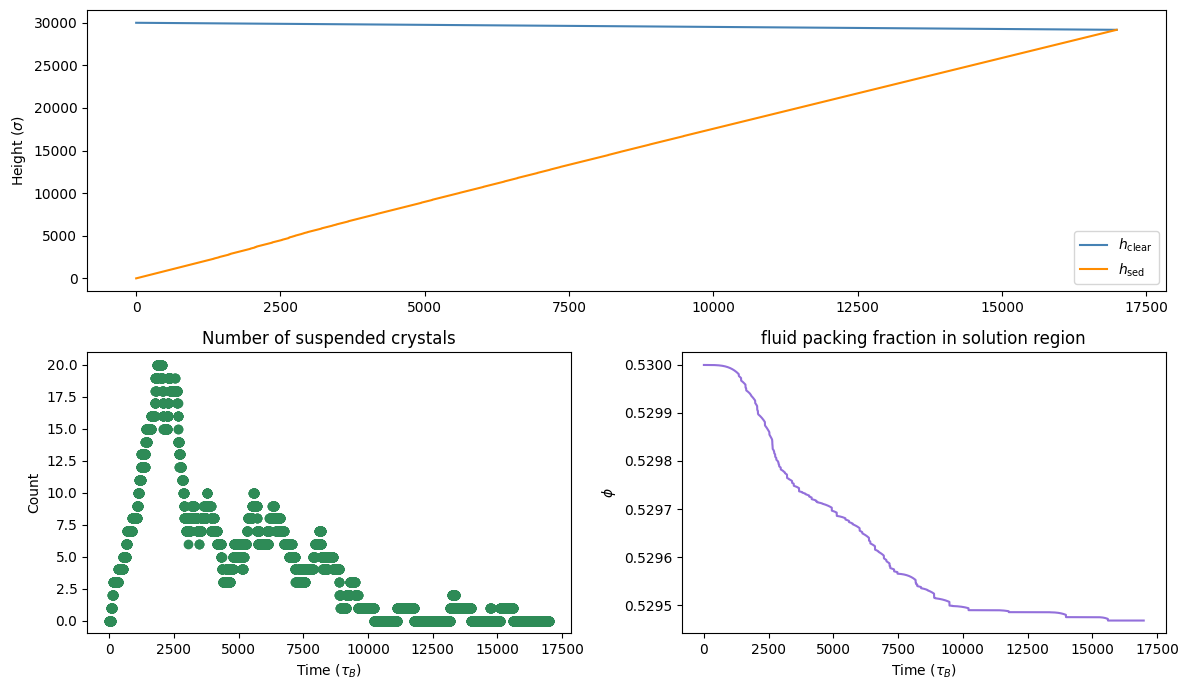

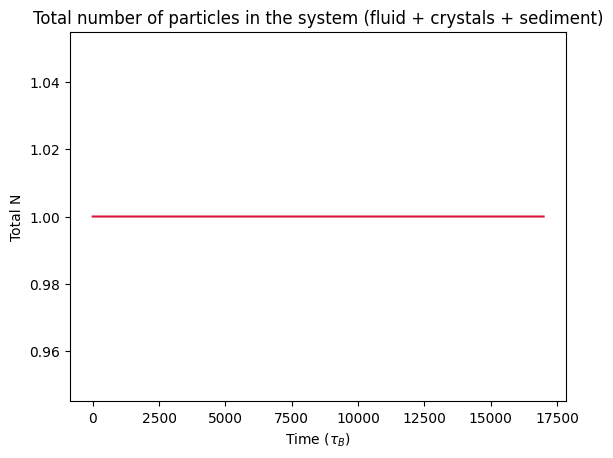

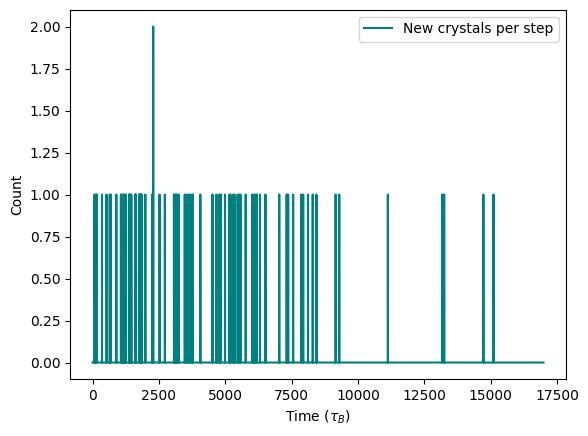

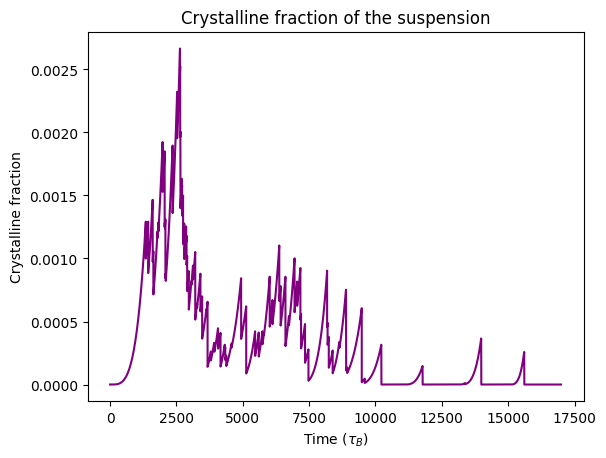

In [30]:
# PLOTTING
_original_subplots = plt.subplots

def _subplots_with_merged_top(*args, **kwargs):
    figsize = kwargs.get("figsize", (12, 7))
    sharex = kwargs.get("sharex", False)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2)

    ax_top = fig.add_subplot(gs[0, :])
    ax_bl = fig.add_subplot(gs[1, 0], sharex=ax_top if sharex else None)
    ax_br = fig.add_subplot(gs[1, 1], sharex=ax_top if sharex else None)

    axes = np.array([[ax_top, ax_top], [ax_bl, ax_br]], dtype=object)
    return fig, axes

plt.subplots = _subplots_with_merged_top

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

axes[0, 0].plot(results['time'], np.array(results['h_clear']) , color='steelblue', label=r'$h_\mathrm{clear}$')
axes[0, 0].set_ylabel(r'Height ($\sigma$)')

axes[0, 1].plot(results['time'], np.array(results['h_sed']), color='darkorange', label=r'$h_\mathrm{sed}$')
# axes[0, 1].set_ylabel('Height ($\sigma$)')

axes[0, 0].legend()
# axes[0, 1].set_title(r'$h_\mathrm{sed}$ — sediment surface')
# axes[0, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].scatter(results['time'], results['n_crystals'], color='seagreen')
axes[1, 0].set_xlabel(r'Time ($\tau_B$)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Number of suspended crystals')

axes[1, 1].plot(results['time'], results['phi_fluid'], color='mediumpurple')
axes[1, 1].set_xlabel(r'Time ($\tau_B$)')
axes[1, 1].set_ylabel(r'$\phi$')
axes[1, 1].set_title('fluid packing fraction in solution region')
# axes[1, 1].set_ylim(0.5298, 0.5305 )

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(results['time'], np.array(results['total_N'])/(H_TOP*AREA*PHI_INITIAL), color='crimson')
plt.xlabel(r'Time ($\tau_B$)')
plt.ylabel('Total N')
plt.title('Total number of particles in the system (fluid + crystals + sediment)')
plt.show()

plt.figure()
plt.plot(results['time'], results['new_crystals'],'-', label='New crystals per step', color='teal')
# plt.plot(results['time'], results['landed_crystals'],'o', mfc='none', label='Landed crystals per step', color='coral', alpha=0.4)
plt.xlabel(r'Time ($\tau_B$)')
plt.ylabel('Count')
# plt.title('New vs Landed crystals per step')
plt.legend()
plt.show()
plt.figure()
plt.plot(results['time'], results['crystalline_fraction_of_suspension'], color='purple')
plt.xlabel(r'Time ($\tau_B$)')
plt.ylabel('Crystalline fraction')
plt.title('Crystalline fraction of the suspension')
plt.show()

In [7]:
hc = np.array(results['h_clear'])


In [16]:
(hc[0] - hc[-1]) / sim.H_TOP


np.float64(0.023853205344636443)

In [15]:
sedimentation_speed(0.53, sim.V_BG, sim.V0_SPHERE, sim.D_SPHERE, model='hayakawa_ichki') / sim.Pe


0.048467879561889735

$$\Delta h_{\text{sed, total}} \sim (\text{events}) \times \frac{V_{\text{NUC}}}{A} \sim A \times \frac{1}{A} = \text{const}$$